# Brazilian E-Commerce Analysis (V2)
**Dataset**: Olist Public Dataset (Kaggle) 

Analisis terhadap 9 dataset relasional dari platform e-commerce terbesar di Brasil. Mencakup analisis tren waktu, segmentasi kategori produk, korelasi multivariabel, dan perbandingan performa antar seller.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'primary': '#1B4F72',
    'secondary': '#2E86C1',
    'accent': '#E67E22',
    'success': '#27AE60',
    'danger': '#E74C3C',
    'dark': '#2C3E50',
    'light': '#ECF0F1',
    'gradient': ['#1B4F72', '#2E86C1', '#5DADE2', '#85C1E9', '#AED6F1'],
    'warm': ['#E74C3C', '#E67E22', '#F1C40F', '#27AE60', '#2E86C1'],
    'cool': ['#1A5276', '#1F618D', '#2471A3', '#2980B9', '#5499C7', '#7FB3D8', '#A9CCE3', '#D4E6F1']
}

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'axes.labelcolor': COLORS['dark'],
    'text.color': COLORS['dark'],
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.color': '#CCCCCC'
})

## 2. Load Seluruh Dataset

In [2]:
customers = pd.read_csv('data/olist_customers_dataset.csv')
orders = pd.read_csv('data/olist_orders_dataset.csv')
order_items = pd.read_csv('data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('data/olist_order_reviews_dataset.csv')
products = pd.read_csv('data/olist_products_dataset.csv')
sellers = pd.read_csv('data/olist_sellers_dataset.csv')
geolocation = pd.read_csv('data/olist_geolocation_dataset.csv')
category_trans = pd.read_csv('data/product_category_name_translation.csv')

datasets = {
    'customers': customers, 'orders': orders, 'order_items': order_items,
    'order_payments': order_payments, 'order_reviews': order_reviews,
    'products': products, 'sellers': sellers, 'geolocation': geolocation,
    'category_translation': category_trans
}

print(f"{'Dataset':<25} {'Baris':>8} {'Kolom':>6}")
print("-" * 42)
for name, df in datasets.items():
    print(f"{name:<25} {len(df):>8,} {len(df.columns):>6}")

Dataset                      Baris  Kolom
------------------------------------------
customers                   99,441      5
orders                      99,441      8
order_items                112,650      7
order_payments             103,886      5
order_reviews               99,224      7
products                    32,951      9
sellers                      3,095      4
geolocation               1,000,163      5
category_translation            71      2


## 3. Data Wrangling: Penggabungan 9 Tabel
Proses penggabungan dilakukan secara bertahap agar setiap langkah dapat diverifikasi. Strategi yang digunakan adalah *left join* dengan tabel `orders` sebagai pusat (*fact table*).

In [3]:
products = pd.merge(products, category_trans, on='product_category_name', how='left')

df = pd.merge(orders, customers[['customer_id', 'customer_unique_id', 'customer_city', 'customer_state']], on='customer_id', how='left')
df = pd.merge(df, order_items, on='order_id', how='left')
df = pd.merge(df, products[['product_id', 'product_category_name_english', 'product_weight_g', 'product_photos_qty']], on='product_id', how='left')
df = pd.merge(df, sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')

payment_agg = order_payments.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    payment_installments=('payment_installments', 'max'),
    payment_type=('payment_type', 'first')
).reset_index()
df = pd.merge(df, payment_agg, on='order_id', how='left')

review_agg = order_reviews.groupby('order_id').agg(
    review_score=('review_score', 'mean'),
    has_comment=('review_comment_message', lambda x: x.notna().any())
).reset_index()
df = pd.merge(df, review_agg, on='order_id', how='left')

print(f"Master DataFrame berhasil dibuat: {df.shape[0]:,} baris x {df.shape[1]} kolom")
print(f"Kolom: {list(df.columns)}")

Master DataFrame berhasil dibuat: 113,425 baris x 27 kolom
Kolom: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name_english', 'product_weight_g', 'product_photos_qty', 'seller_city', 'seller_state', 'total_payment', 'payment_installments', 'payment_type', 'review_score', 'has_comment']


## 4. Data Cleaning & Feature Engineering

In [4]:
df.dropna(subset=['product_id'], inplace=True)

date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days
df['delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late'] = df['delay_days'] > 0
df['approval_hours'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / 3600

df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df['order_weekday'] = df['order_purchase_timestamp'].dt.day_name()
df['order_hour'] = df['order_purchase_timestamp'].dt.hour

df['total_item_value'] = df['price'] + df['freight_value']
df['freight_ratio'] = df['freight_value'] / df['total_item_value']

df['is_same_state'] = df['customer_state'] == df['seller_state']

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = missing[missing > 0].to_frame('count')
missing_report['persen'] = missing_pct[missing > 0]
print("Kolom dengan nilai kosong:")
print(missing_report.sort_values('count', ascending=False))

Kolom dengan nilai kosong:
                               count  persen
order_delivered_customer_date   2454    2.18
delay_days                      2454    2.18
delivery_days                   2454    2.18
product_category_name_english   1627    1.44
product_photos_qty              1603    1.42
order_delivered_carrier_date    1194    1.06
review_score                     942    0.84
has_comment                      942    0.84
product_weight_g                  18    0.02
order_approved_at                 15    0.01
approval_hours                    15    0.01
payment_type                       3    0.00
total_payment                      3    0.00
payment_installments               3    0.00


## 5. Tren Penjualan Bulanan
Bagaimana pertumbuhan pesanan Olist dari waktu ke waktu?

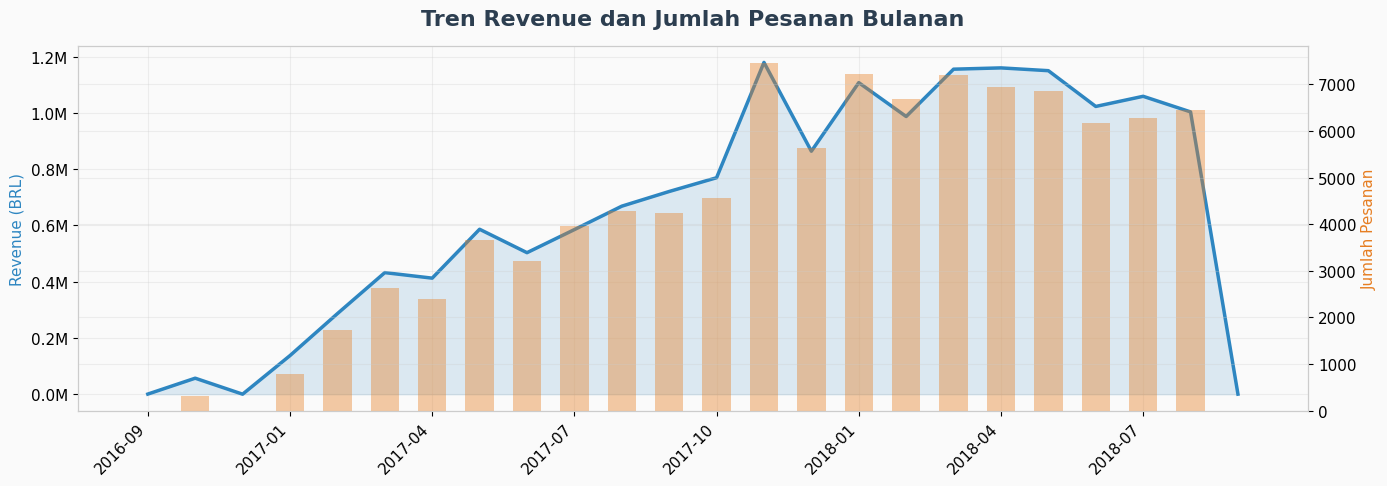

In [5]:
monthly = df.groupby('order_month').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_item_value', 'sum'),
    avg_ticket=('total_item_value', 'mean')
).reset_index()
monthly['order_month_str'] = monthly['order_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(range(len(monthly)), monthly['revenue'], alpha=0.15, color=COLORS['secondary'])
ax1.plot(range(len(monthly)), monthly['revenue'], color=COLORS['secondary'], linewidth=2.5, label='Revenue (BRL)')
ax1.set_ylabel('Revenue (BRL)', color=COLORS['secondary'])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

ax2 = ax1.twinx()
ax2.bar(range(len(monthly)), monthly['orders'], alpha=0.4, color=COLORS['accent'], width=0.6, label='Jumlah Pesanan')
ax2.set_ylabel('Jumlah Pesanan', color=COLORS['accent'])

tick_positions = list(range(0, len(monthly), 3))
ax1.set_xticks(tick_positions)
ax1.set_xticklabels([monthly['order_month_str'].iloc[i] for i in tick_positions], rotation=45, ha='right')

plt.title('Tren Revenue dan Jumlah Pesanan Bulanan', fontsize=16, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

## 6. Pola Waktu Pembelian
Kapan pelanggan paling sering berbelanja?

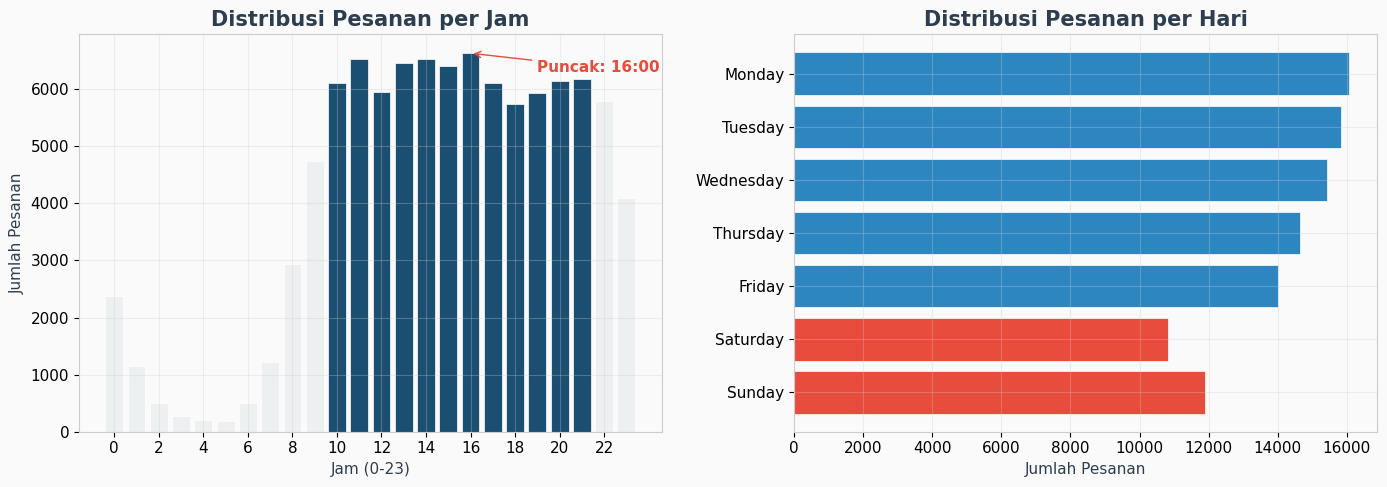

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly = df.groupby('order_hour')['order_id'].nunique()
axes[0].bar(hourly.index, hourly.values, color=[COLORS['primary'] if h in range(10, 22) else COLORS['light'] for h in hourly.index], edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribusi Pesanan per Jam')
axes[0].set_xlabel('Jam (0-23)')
axes[0].set_ylabel('Jumlah Pesanan')
axes[0].set_xticks(range(0, 24, 2))
peak_hour = hourly.idxmax()
axes[0].annotate(f'Puncak: {peak_hour}:00', xy=(peak_hour, hourly.max()),
                xytext=(peak_hour + 3, hourly.max() * 0.95),
                arrowprops=dict(arrowstyle='->', color=COLORS['danger']),
                fontsize=11, color=COLORS['danger'], fontweight='bold')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df.groupby('order_weekday')['order_id'].nunique().reindex(day_order)
bar_colors = [COLORS['danger'] if d in ['Saturday', 'Sunday'] else COLORS['secondary'] for d in day_order]
axes[1].barh(daily.index, daily.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Distribusi Pesanan per Hari')
axes[1].set_xlabel('Jumlah Pesanan')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Analisis Geospasial: Top States & Cities

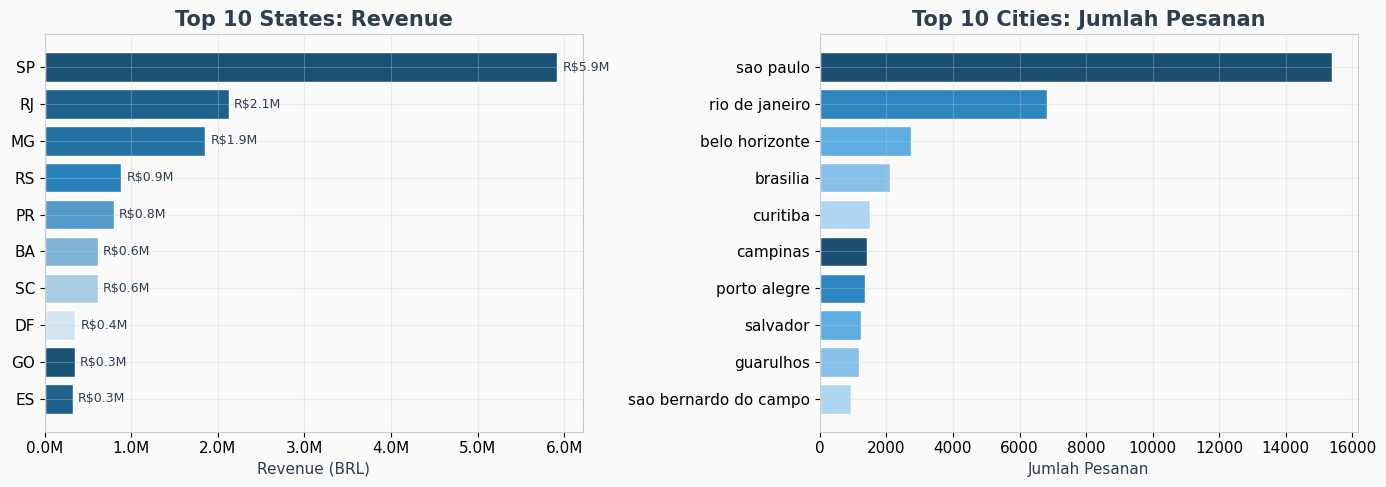

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

state_data = df.groupby('customer_state').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_item_value', 'sum')
).sort_values('revenue', ascending=False).head(10).reset_index()

bars = axes[0].barh(state_data['customer_state'], state_data['revenue'], color=COLORS['cool'][:len(state_data)], edgecolor='white')
axes[0].set_title('Top 10 States: Revenue')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].invert_yaxis()
for bar, val in zip(bars, state_data['revenue']):
    axes[0].text(val + state_data['revenue'].max() * 0.01, bar.get_y() + bar.get_height()/2,
                f'R${val/1e6:.1f}M', va='center', fontsize=9)

city_data = df.groupby('customer_city')['order_id'].nunique().sort_values(ascending=False).head(10).reset_index()
city_data.columns = ['city', 'orders']
axes[1].barh(city_data['city'], city_data['orders'], color=COLORS['gradient'][:5] + COLORS['gradient'][:5], edgecolor='white')
axes[1].set_title('Top 10 Cities: Jumlah Pesanan')
axes[1].set_xlabel('Jumlah Pesanan')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Analisis Kategori Produk
Kategori produk apa yang paling menguntungkan, dan bagaimana distribusi harganya?

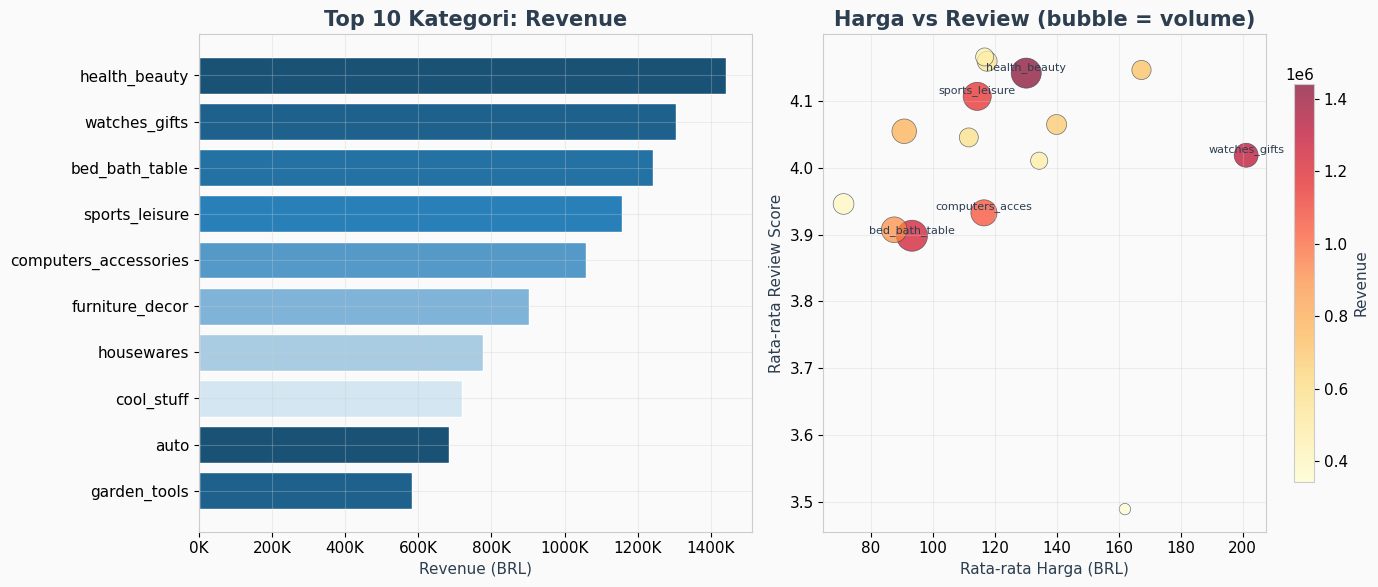

In [8]:
cat_data = df.groupby('product_category_name_english').agg(
    orders=('order_id', 'nunique'),
    revenue=('total_item_value', 'sum'),
    avg_price=('price', 'mean'),
    avg_review=('review_score', 'mean')
).sort_values('revenue', ascending=False).head(15).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(cat_data['product_category_name_english'][:10], cat_data['revenue'][:10],
            color=COLORS['cool'][:10], edgecolor='white')
axes[0].set_title('Top 10 Kategori: Revenue')
axes[0].set_xlabel('Revenue (BRL)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[0].invert_yaxis()

sc = axes[1].scatter(cat_data['avg_price'], cat_data['avg_review'],
                     s=cat_data['orders'] / cat_data['orders'].max() * 500,
                     c=cat_data['revenue'], cmap='YlOrRd', alpha=0.7, edgecolors=COLORS['dark'], linewidth=0.5)
axes[1].set_title('Harga vs Review (bubble = volume)')
axes[1].set_xlabel('Rata-rata Harga (BRL)')
axes[1].set_ylabel('Rata-rata Review Score')
for i, row in cat_data.head(5).iterrows():
    axes[1].annotate(row['product_category_name_english'][:15],
                    (row['avg_price'], row['avg_review']),
                    fontsize=8, ha='center', va='bottom')
plt.colorbar(sc, ax=axes[1], label='Revenue', shrink=0.8)

plt.tight_layout()
plt.show()

## 9. Kinerja Pengiriman Mendalam
Analisis keterlambatan yang lebih granular: per state, per kategori, dan hubungannya dengan jarak pengiriman.

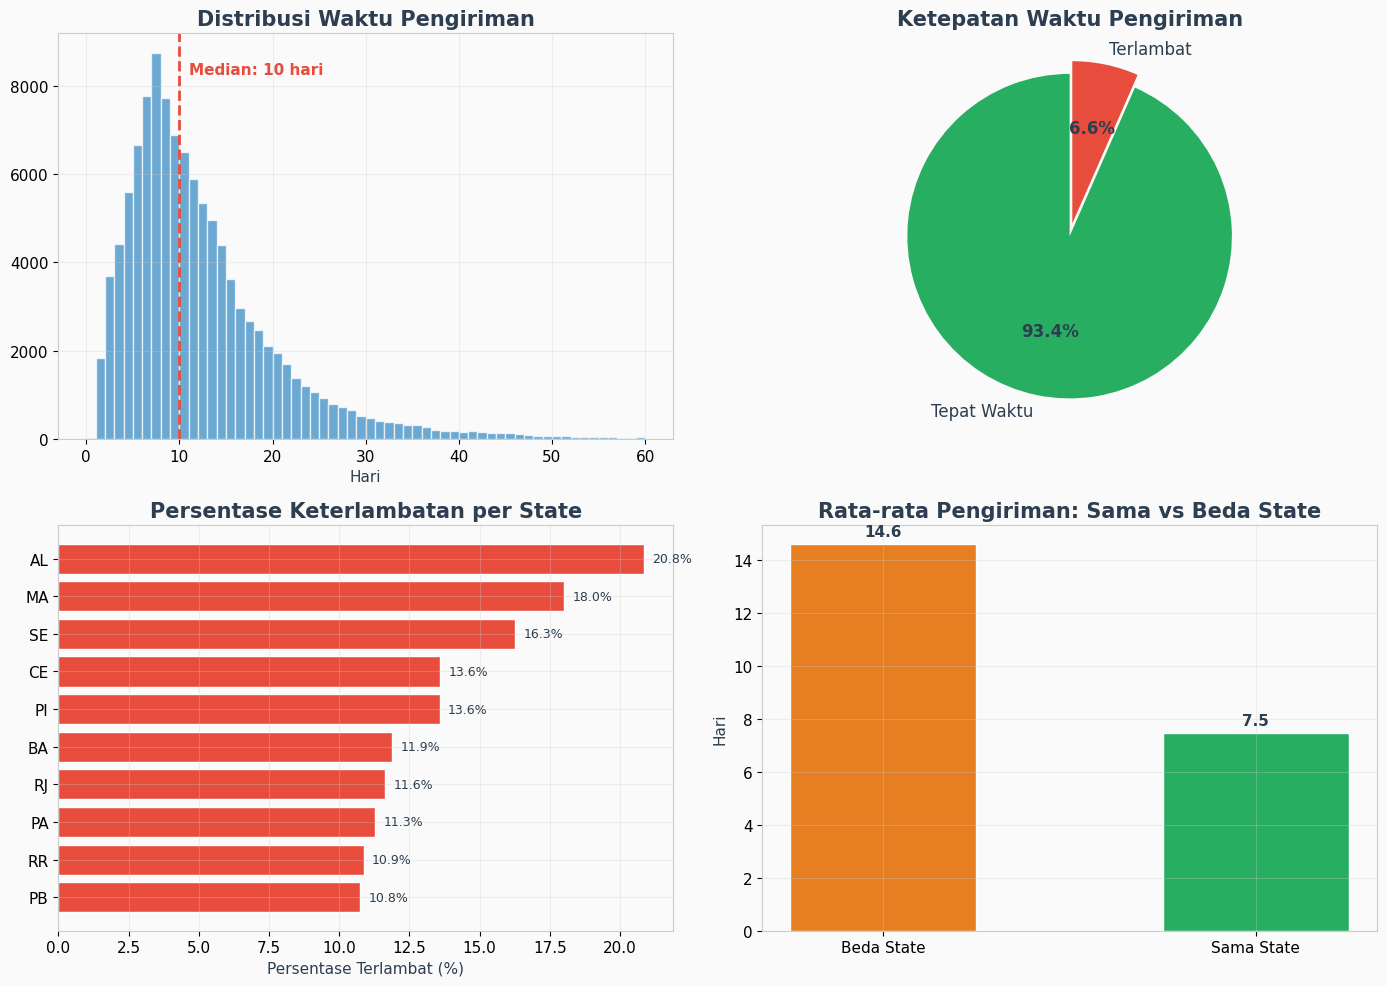

In [9]:
delivered = df[df['order_status'] == 'delivered'].dropna(subset=['delivery_days', 'delay_days'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(delivered['delivery_days'], bins=60, range=(0, 60), color=COLORS['secondary'], alpha=0.7, edgecolor='white')
median_d = delivered['delivery_days'].median()
axes[0, 0].axvline(median_d, color=COLORS['danger'], linestyle='--', linewidth=2)
axes[0, 0].text(median_d + 1, axes[0, 0].get_ylim()[1] * 0.9, f'Median: {median_d:.0f} hari',
               color=COLORS['danger'], fontweight='bold')
axes[0, 0].set_title('Distribusi Waktu Pengiriman')
axes[0, 0].set_xlabel('Hari')

late_pct = delivered['is_late'].value_counts(normalize=True) * 100
colors_pie = [COLORS['success'], COLORS['danger']]
wedges, texts, autotexts = axes[0, 1].pie(late_pct, labels=['Tepat Waktu', 'Terlambat'],
                                           autopct='%1.1f%%', colors=colors_pie,
                                           startangle=90, explode=[0, 0.08],
                                           textprops={'fontsize': 12})
autotexts[0].set_fontweight('bold')
autotexts[1].set_fontweight('bold')
axes[0, 1].set_title('Ketepatan Waktu Pengiriman')

state_late = delivered.groupby('customer_state')['is_late'].mean().sort_values(ascending=False).head(10) * 100
axes[1, 0].barh(state_late.index, state_late.values, color=[COLORS['danger'] if v > 10 else COLORS['accent'] for v in state_late.values], edgecolor='white')
axes[1, 0].set_title('Persentase Keterlambatan per State')
axes[1, 0].set_xlabel('Persentase Terlambat (%)')
axes[1, 0].invert_yaxis()
for i, v in enumerate(state_late.values):
    axes[1, 0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

same_state = delivered.groupby('is_same_state')['delivery_days'].mean()
labels_ss = ['Beda State', 'Sama State']
bar_ss = axes[1, 1].bar(labels_ss, same_state.values, color=[COLORS['accent'], COLORS['success']], width=0.5, edgecolor='white')
axes[1, 1].set_title('Rata-rata Pengiriman: Sama vs Beda State')
axes[1, 1].set_ylabel('Hari')
for bar, val in zip(bar_ss, same_state.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Metode Pembayaran & Perilaku Cicilan

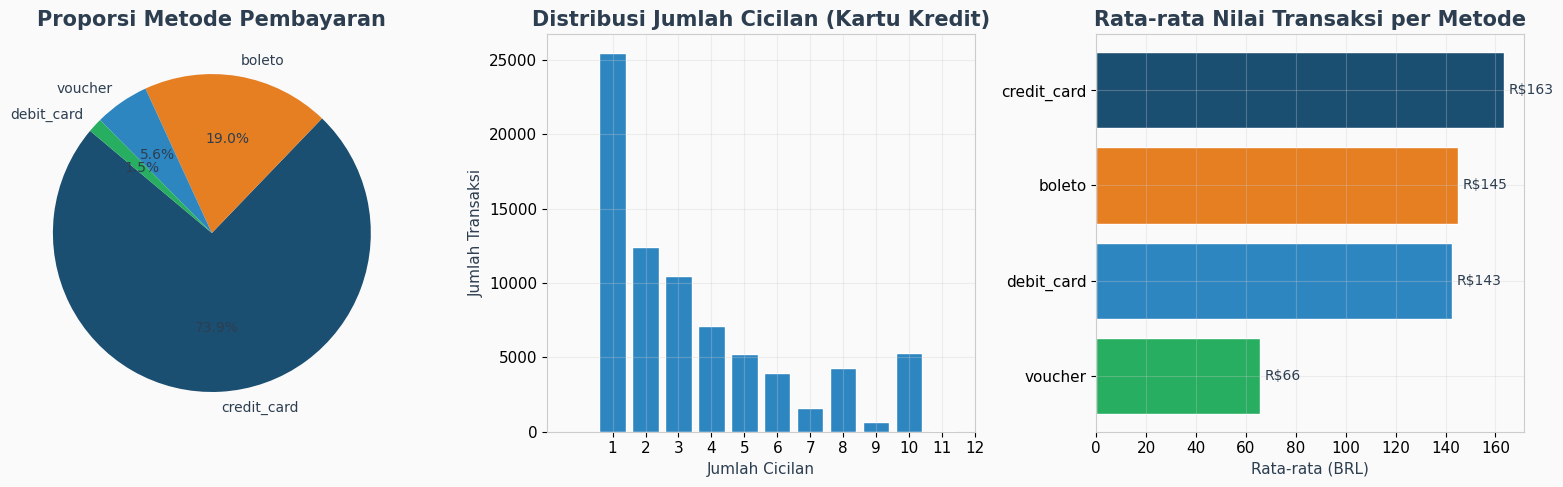

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pay_counts = order_payments['payment_type'].value_counts()
pay_counts = pay_counts[pay_counts.index != 'not_defined']
colors_pay = [COLORS['primary'], COLORS['accent'], COLORS['secondary'], COLORS['success']]
wedges, texts, autotexts = axes[0].pie(pay_counts, labels=pay_counts.index, autopct='%1.1f%%',
                                        colors=colors_pay, startangle=140, textprops={'fontsize': 10})
axes[0].set_title('Proporsi Metode Pembayaran')

cc = order_payments[order_payments['payment_type'] == 'credit_card']
installment_dist = cc['payment_installments'].value_counts().sort_index().head(12)
axes[1].bar(installment_dist.index, installment_dist.values, color=COLORS['gradient'][1], edgecolor='white')
axes[1].set_title('Distribusi Jumlah Cicilan (Kartu Kredit)')
axes[1].set_xlabel('Jumlah Cicilan')
axes[1].set_ylabel('Jumlah Transaksi')
axes[1].set_xticks(range(1, 13))

avg_by_type = order_payments.groupby('payment_type')['payment_value'].mean().sort_values(ascending=False)
avg_by_type = avg_by_type[avg_by_type.index != 'not_defined']
axes[2].barh(avg_by_type.index, avg_by_type.values, color=colors_pay[:len(avg_by_type)], edgecolor='white')
axes[2].set_title('Rata-rata Nilai Transaksi per Metode')
axes[2].set_xlabel('Rata-rata (BRL)')
axes[2].invert_yaxis()
for i, v in enumerate(avg_by_type.values):
    axes[2].text(v + 2, i, f'R${v:.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Kepuasan Pelanggan & Faktor Penyebabnya

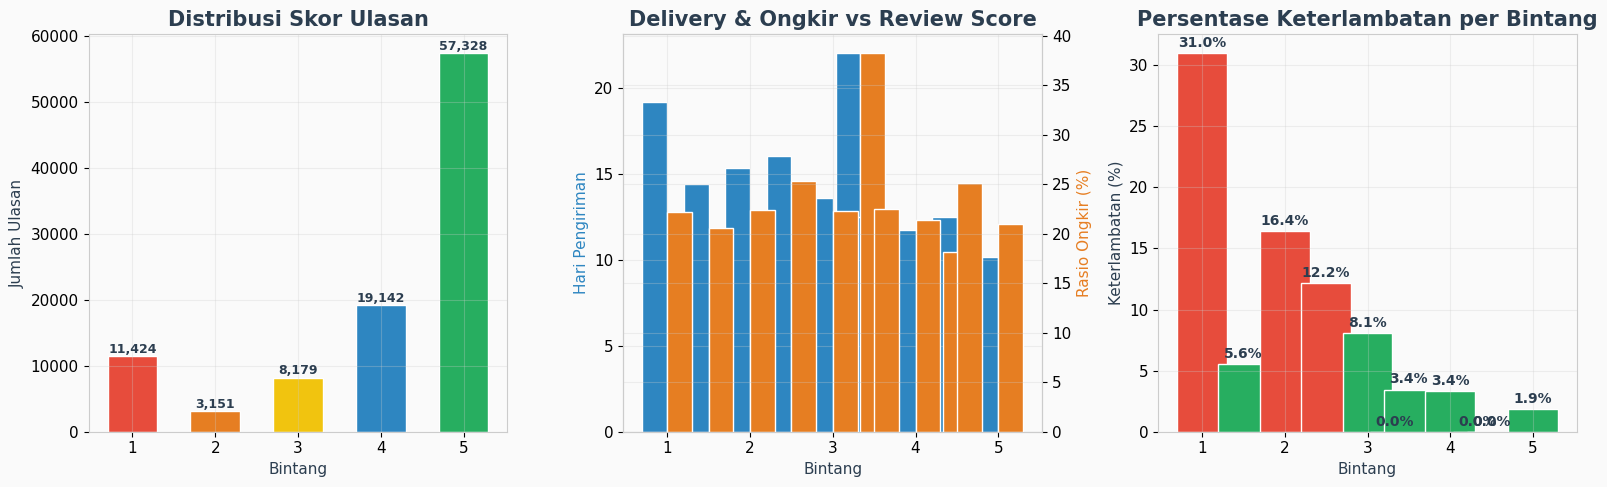

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

review_dist = order_reviews['review_score'].value_counts().sort_index()
bar_colors_r = [COLORS['danger'], COLORS['accent'], '#F1C40F', COLORS['secondary'], COLORS['success']]
axes[0].bar(review_dist.index, review_dist.values, color=bar_colors_r, edgecolor='white', width=0.6)
axes[0].set_title('Distribusi Skor Ulasan')
axes[0].set_xlabel('Bintang')
axes[0].set_ylabel('Jumlah Ulasan')
for i, (score, count) in enumerate(review_dist.items()):
    axes[0].text(score, count + 500, f'{count:,}', ha='center', fontsize=9, fontweight='bold')

avg_by_score = delivered.groupby('review_score')[['delivery_days', 'freight_ratio']].mean()
ax_twin = axes[1].twinx()
axes[1].bar(avg_by_score.index - 0.15, avg_by_score['delivery_days'], width=0.3,
           color=COLORS['secondary'], label='Waktu Kirim (hari)', edgecolor='white')
ax_twin.bar(avg_by_score.index + 0.15, avg_by_score['freight_ratio'] * 100, width=0.3,
           color=COLORS['accent'], label='Rasio Ongkir (%)', edgecolor='white')
axes[1].set_title('Delivery & Ongkir vs Review Score')
axes[1].set_xlabel('Bintang')
axes[1].set_ylabel('Hari Pengiriman', color=COLORS['secondary'])
ax_twin.set_ylabel('Rasio Ongkir (%)', color=COLORS['accent'])
axes[1].set_xticks([1, 2, 3, 4, 5])

late_by_score = delivered.groupby('review_score')['is_late'].mean() * 100
axes[2].bar(late_by_score.index, late_by_score.values,
           color=[COLORS['danger'] if v > 10 else COLORS['success'] for v in late_by_score.values],
           edgecolor='white', width=0.6)
axes[2].set_title('Persentase Keterlambatan per Bintang')
axes[2].set_xlabel('Bintang')
axes[2].set_ylabel('Keterlambatan (%)')
for score, val in late_by_score.items():
    axes[2].text(score, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Analisis Performa Seller

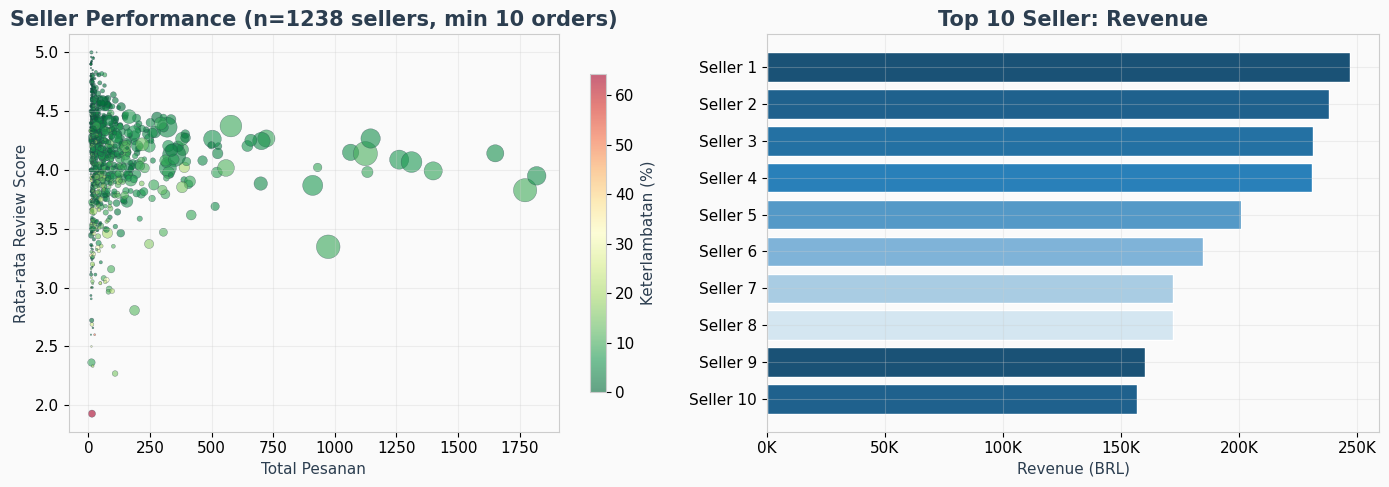

Total seller aktif (min 10 pesanan): 1238
Rata-rata review seluruh seller aktif: 4.13
Rata-rata keterlambatan seller aktif: 6.4%


In [12]:
seller_perf = df[df['order_status'] == 'delivered'].groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    total_revenue=('total_item_value', 'sum'),
    avg_review=('review_score', 'mean'),
    avg_delivery=('delivery_days', 'mean'),
    late_pct=('is_late', 'mean')
).reset_index()

seller_perf['late_pct'] = seller_perf['late_pct'] * 100
active_sellers = seller_perf[seller_perf['total_orders'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(active_sellers['total_orders'], active_sellers['avg_review'],
                      s=active_sellers['total_revenue'] / active_sellers['total_revenue'].max() * 300,
                      c=active_sellers['late_pct'], cmap='RdYlGn_r', alpha=0.6,
                      edgecolors=COLORS['dark'], linewidth=0.3)
axes[0].set_title(f'Seller Performance (n={len(active_sellers)} sellers, min 10 orders)')
axes[0].set_xlabel('Total Pesanan')
axes[0].set_ylabel('Rata-rata Review Score')
plt.colorbar(sc1, ax=axes[0], label='Keterlambatan (%)', shrink=0.8)

top_sellers = active_sellers.nlargest(10, 'total_revenue')
axes[1].barh(range(10), top_sellers['total_revenue'], color=COLORS['cool'][:10], edgecolor='white')
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([f"Seller {i+1}" for i in range(10)])
axes[1].set_title('Top 10 Seller: Revenue')
axes[1].set_xlabel('Revenue (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Total seller aktif (min 10 pesanan): {len(active_sellers)}")
print(f"Rata-rata review seluruh seller aktif: {active_sellers['avg_review'].mean():.2f}")
print(f"Rata-rata keterlambatan seller aktif: {active_sellers['late_pct'].mean():.1f}%")

## 13. Korelasi Antar Variabel Numerik

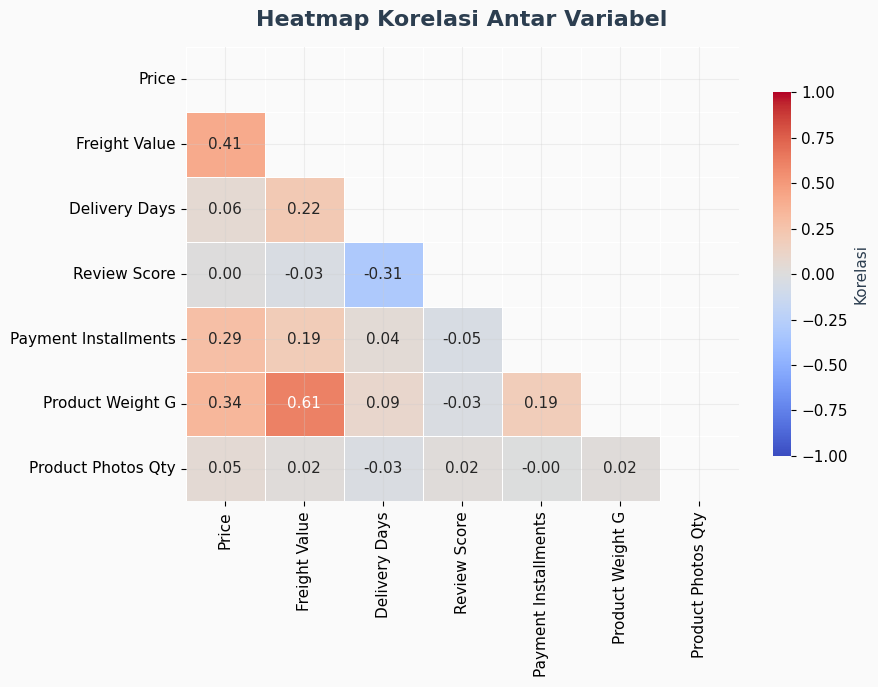

In [13]:
corr_cols = ['price', 'freight_value', 'delivery_days', 'review_score',
            'payment_installments', 'product_weight_g', 'product_photos_qty']
corr_df = delivered[corr_cols].dropna()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Korelasi'},
            xticklabels=[c.replace('_', ' ').title() for c in corr_cols],
            yticklabels=[c.replace('_', ' ').title() for c in corr_cols])
plt.title('Heatmap Korelasi Antar Variabel', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

## 14. Kesimpulan & Rekomendasi Bisnis

### Temuan Utama
1. **Pertumbuhan Signifikan**: Olist mengalami pertumbuhan pesanan dan revenue yang konsisten dari 2017 ke 2018, menandakan adopsi e-commerce yang pesat di Brasil.

2. **Dominasi Geografis**: Sao Paulo (SP) menyumbang porsi terbesar baik dari sisi pesanan maupun revenue. Lima negara bagian teratas sudah mencakup lebih dari 70% seluruh transaksi.

3. **Logistik adalah Kunci Kepuasan**: Terdapat korelasi negatif yang kuat antara waktu pengiriman dengan review score. Pesanan yang terlambat memiliki kemungkinan jauh lebih besar untuk menerima ulasan bintang 1. Pengiriman dalam state yang sama secara signifikan lebih cepat.

4. **Kartu Kredit Mendominasi**: Lebih dari 73% transaksi menggunakan kartu kredit, dengan mayoritas memilih opsi 1 kali bayar (tanpa cicilan). Namun, transaksi bernilai tinggi cenderung dicicil hingga 10-12 kali.

5. **Kategori Teratas**: Health & beauty, watches & gifts, dan bed/bath/table menghasilkan revenue tertinggi. Namun, kategori dengan harga rata-rata tinggi belum tentu memiliki review score terbaik.

6. **Variasi Performa Seller**: Terdapat disparitas besar antar seller. Seller dengan volume tinggi cenderung memiliki persentase keterlambatan yang lebih rendah, mengindikasikan bahwa pengalaman operasional berperan penting.

### Rekomendasi
1. **Optimasi Logistik Regional**: Prioritaskan pembangunan gudang atau hub distribusi di state dengan keterlambatan tertinggi.
2. **Program Insentif Seller**: Berikan badge atau prioritas listing untuk seller dengan performa pengiriman dan review yang konsisten baik.
3. **Ekspansi Strategis**: Negara bagian di luar SP-RJ-MG masih memiliki potensi pertumbuhan besar yang belum tergarap maksimal.
4. **Optimasi Ongkos Kirim**: Rasio ongkir terhadap total harga yang terlalu tinggi berkorelasi dengan review yang lebih rendah. Pertimbangkan subsidi ongkir untuk kategori tertentu.